# Hotspot Detector 테스트

이미지에서 발화 지점(Hotspots)을 탐지하는 노드를 테스트합니다.

In [1]:
# Test Image Filename
TEST_IMAGE_FILENAME = "IMG_8113.jpg"

In [2]:
# 환경 설정 및 이미지 로드
import sys
from pathlib import Path

# 프로젝트 루트 경로 설정
current_dir = Path.cwd()
project_root = current_dir.parent if current_dir.name == "notebook" else current_dir
sys.path.insert(0, str(project_root))

# 환경 변수 로드
from dotenv import load_dotenv
load_dotenv(project_root / ".env")

print(f"✓ 현재 디렉토리: {current_dir}")
print(f"✓ 프로젝트 루트: {project_root}")

# 테스트 이미지 준비
from src.utils import find_data_directory
from src.tools.experts.expert_utils import save_bytes_to_temp_file

data_dir = project_root / "data"
if not data_dir.exists():
    data_dir = Path(find_data_directory())
print(f"✓ Data 디렉토리: {data_dir}")

try:
    test_image_name = (TEST_IMAGE_FILENAME or "").strip() or "Poor_Contact_001.jpg"
except NameError:
    test_image_name = "Poor_Contact_001.jpg"
    print("⚠️ TEST_IMAGE_FILENAME 미정의, 기본값 사용")

test_image_path = data_dir / test_image_name
if not test_image_path.exists():
    image_files = list(data_dir.glob("*.png")) + list(data_dir.glob("*.jpg")) + list(data_dir.glob("*.JPG"))
    test_image_path = image_files[0] if image_files else None
    if test_image_path:
        print(f"⚠️ 지정 이미지 없음, {test_image_path.name} 사용")

if not test_image_path or not test_image_path.exists():
    raise FileNotFoundError("테스트할 이미지가 없습니다.")

print(f"✓ 테스트 이미지: {test_image_path}")
with open(test_image_path, "rb") as f:
    image_data = f.read()
temp_image_path = save_bytes_to_temp_file(image_data)
print(f"✓ 임시 이미지 경로: {temp_image_path}")

✓ 현재 디렉토리: c:\Users\loidn\Documents\Projects\P_04_Scope\notebook
✓ 프로젝트 루트: c:\Users\loidn\Documents\Projects\P_04_Scope
✓ Data 디렉토리: c:\Users\loidn\Documents\Projects\P_04_Scope\data
✓ 테스트 이미지: c:\Users\loidn\Documents\Projects\P_04_Scope\data\IMG_8113.jpg
✓ 임시 이미지 경로: C:\Users\loidn\AppData\Local\Temp\tmpiabnxvu7.jpg


In [3]:
# Hotspot Detector 호출
from src.nodes.common_nodes import hotspot_detector_node
from src.state import InvestigationState

temp_investigation_state = InvestigationState(
    payload=[],
    image_path=temp_image_path,
    hotspots=None,
    expert_reports=[],
    expert_analysis_results={},
    expert_confidence_scores={},
    expert_evidence={},
    final_verdict=None,
    errors=[],
)

print("✓ Hotspot 탐지 중...")
hotspot_result = hotspot_detector_node(temp_investigation_state)
detected_hotspots = hotspot_result.get("hotspots", [])
errors = hotspot_result.get("errors", [])
analysis_status = hotspot_result.get("analysis_status", "")
corrected_total = hotspot_result.get("corrected_total_count", len(detected_hotspots))

print(f"✓ 탐지된 Hotspots: {len(detected_hotspots)}개 (corrected_total_count: {corrected_total})")
if analysis_status:
    print(f"✓ analysis_status: {analysis_status}")
if errors:
    print("⚠️ 경고:", errors)

✓ Hotspot 탐지 중...
2026-02-07 09:15:56 [INFO] common_nodes.hotspot_detector_node: Hotspot Detector: Using existing image path: C:\Users\loidn\AppData\Local\Temp\tmpiabnxvu7.jpg
2026-02-07 09:15:56 [INFO] common_nodes.hotspot_detector_node: Hotspot Detector: Starting analysis (Image: C:\Users\loidn\AppData\Local\Temp\tmpiabnxvu7.jpg)
2026-02-07 09:16:36 [INFO] common_nodes._call_hotspot_api: Hotspot raw response: total_count=4, len(hotspots)=4, hotspots_type=list, raw_keys=['hotspots', 'total_count', 'analysis_summary', 'scene_overview', 'detailed_observations']
2026-02-07 09:16:36 [INFO] common_nodes.hotspot_detector_node: Hotspot Detector: Found 4 hotspots
2026-02-07 09:16:36 [INFO] common_nodes.hotspot_detector_node:    - ID 1: bead_formation (Score: 92)
2026-02-07 09:16:36 [INFO] common_nodes.hotspot_detector_node:    - ID 2: carbonization (Score: 78)
2026-02-07 09:16:36 [INFO] common_nodes.hotspot_detector_node:    - ID 3: insulation_melting (Score: 65)
2026-02-07 09:16:36 [INFO] co

In [4]:
# 결과 표시 (테이블)
if detected_hotspots:
    header = f"{'ID':<4} {'damage_type':<20} {'severity':<8} {'location':<20} box_2d"
    print(header)
    print("-" * 80)
    for h in detected_hotspots:
        box = h.get("box_2d", {})
        if isinstance(box, dict):
            box_str = f"({box.get('xmin',0)},{box.get('ymin',0)})-({box.get('xmax',0)},{box.get('ymax',0)})"
        else:
            box_str = str(box)
        loc = (h.get("location_description") or "")[:18]
        print(f"{h.get('id', ''):<4} {str(h.get('damage_type','')):<20} {h.get('severity_score',''):<8} {loc:<20} {box_str}")
else:
    print("탐지된 Hotspot이 없습니다.")

ID   damage_type          severity location             box_2d
--------------------------------------------------------------------------------
1    bead_formation       92       중앙 좌측 도체 끝단          (418,338)-(451,376)
2    carbonization        78       우측 하단 커넥터 하우징        (834,472)-(878,586)
3    insulation_melting   65       우측 상단 전선 인입부         (709,351)-(841,421)
4    thermal_damage       52       우측 중앙 금속 단자          (884,435)-(989,472)


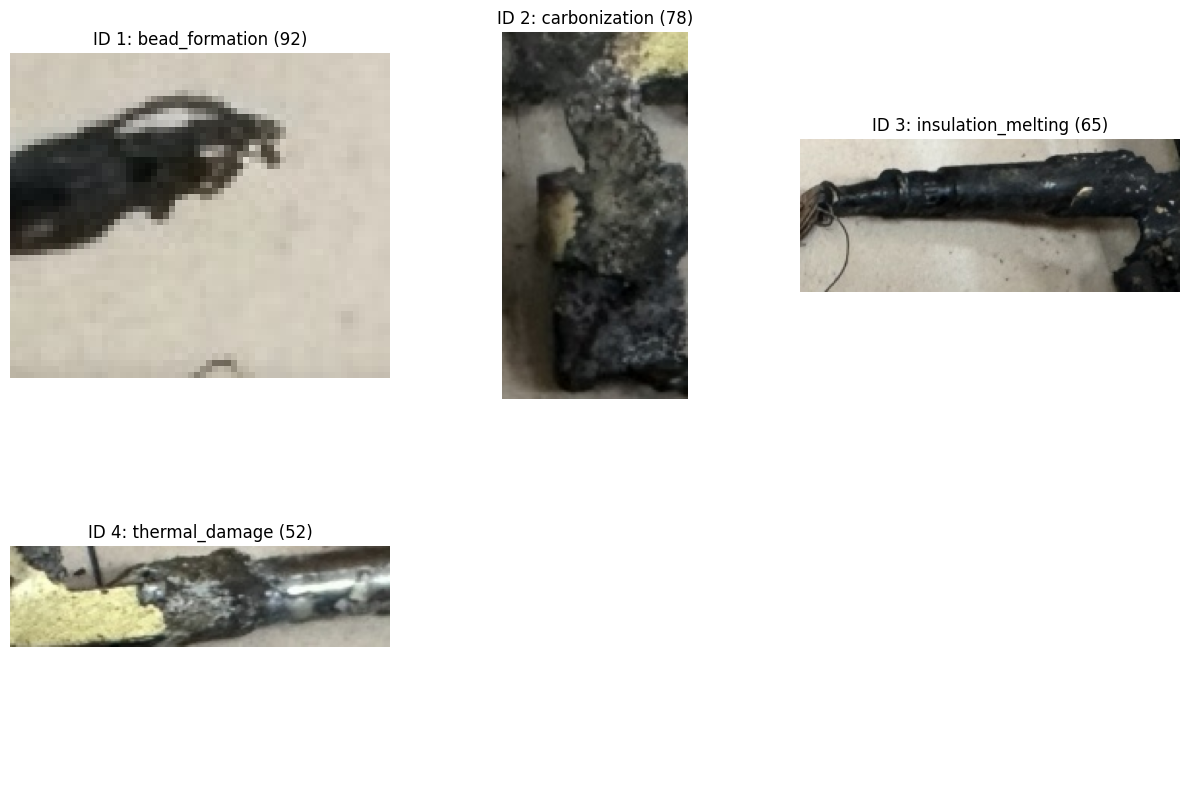

In [5]:
# 시각화: 각 Hotspot ROI 크롭 후 그리드로 표시
import numpy as np
from src.utils import crop_roi_from_box
import matplotlib.pyplot as plt
from PIL import Image

if detected_hotspots:
    n = min(len(detected_hotspots), 6)
    cols = 3
    rows = (n + cols - 1) // cols
    fig, axes = plt.subplots(rows, cols, figsize=(12, 4 * rows))
    axes_flat = np.atleast_2d(axes)
    for i, h in enumerate(detected_hotspots[:n]):
        box_2d = h.get("box_2d")
        if box_2d:
            cropped_path = crop_roi_from_box(temp_image_path, box_2d)
            img = Image.open(cropped_path)
            ax = axes_flat.flat[i]
            ax.imshow(img)
            ax.set_title(f"ID {h.get('id')}: {h.get('damage_type')} ({h.get('severity_score')})")
            ax.axis("off")
    for j in range(n, rows * cols):
        axes_flat.flat[j].axis("off")
    plt.tight_layout()
    plt.show()
else:
    print("시각화할 Hotspot이 없습니다.")